# Causal Inference: Difference-in-Differences & Regression Discontinuity

## *Workshop 8*  [![Open In Colab](https://github.com/oballinger/BASC0005/blob/main/colab-badge.png?raw=1)](https://colab.research.google.com/github/oballinger/BASC0005/blob/main/notebooks/W08.%20Causal%20Inference.ipynb)

### Aims:

This workshop follows the lecture. We practise the two designs it covers, and the checks that tell you whether to believe them.

1. **Why correlation isn't enough**: a cross-state correlation between minimum wages and unemployment, and why it is endogenous
2. **Difference-in-Differences (DiD)**: New Jersey's 2014 minimum wage rise, with Pennsylvania as the control
    * the 2x2 table by hand, then the same number from a regression with an interaction
    * county fixed effects and clustered standard errors (only as much as DiD needs)
    * parallel trends: an event-study plot and placebo tests
3. **Regression Discontinuity (RDD)**: does being allowed to drink at 21 kill people?
    * plot the discontinuity, fit a linear model with different slopes
    * bandwidth sensitivity, a placebo outcome, and a manipulation (McCrary) check
    * *optional*: fuzzy RDD and the "sheepskin effect"
4. **Audit a causal claim**: two flawed analyses to diagnose with the lecture's checklist

Timing guide for the 2 hours: Part 1 about 10 min, Part 2 about 45 min, Part 3 about 40 min, Part 4 about 20 min. Sections marked *optional* are extensions.

## Getting Started

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)

We use three datasets, all already hosted:

* `state_data.csv`: monthly unemployment rate (%) for every U.S. state 1976–2022, plus the state minimum wage (**in 2020 dollars**, so it drifts down with inflation between rises) and state GDP (from 1997). Sources: BLS, Vaghul & Zipperer's minimum wage series, BEA.
* `county_labor.csv`: annual unemployment rate and population (thousands) for every U.S. county 2008–2021 (BLS Local Area Unemployment Statistics).
* `drinking.csv` and `sheepskin.csv`: the RDD examples, from Carpenter & Dobkin (2009) and Clark & Martorell (2014).

In [2]:
states = pd.read_csv('https://storage.googleapis.com/qm2/wk10/state_data.csv', parse_dates=['date'])
counties = pd.read_csv('https://storage.googleapis.com/qm2/wk10/county_labor.csv')
counties['county_fips'] = counties['county_fips'].astype(str).str.zfill(5)  # 5-digit FIPS code: first 2 digits = state

# annual state averages are enough for most of what we do
states_yr = states.groupby(['state', 'year'], as_index=False)[['unemployment', 'minwage', 'fedminwage', 'gdp']].mean()
states_yr.head()

,state,year,unemployment,minwage,fedminwage,gdp
0,alabama,1976,6.700000,0.0,10.00,NaN
1,alabama,1977,7.150000,0.0,9.39,NaN
2,alabama,1978,6.408333,0.0,8.73,NaN
3,alabama,1979,7.225000,0.0,10.33,NaN
4,alabama,1980,8.816667,0.0,9.73,NaN


***
## 1. Why correlation isn't enough

Politicians argue about minimum wages all the time. One side says higher minimum wages lift workers out of poverty; the other says they price low-skilled workers out of jobs. Let's start the way a naive analyst would: pool every state and every year from 2000 to 2019, and see whether higher minimum wages go with higher unemployment.

Note that some states have **no state minimum wage** at all. They are coded `0` in `minwage`, but workers there are still covered by the federal minimum. So the wage that actually binds is the larger of the two. (Always check what a `0` means before you run a regression on it.)

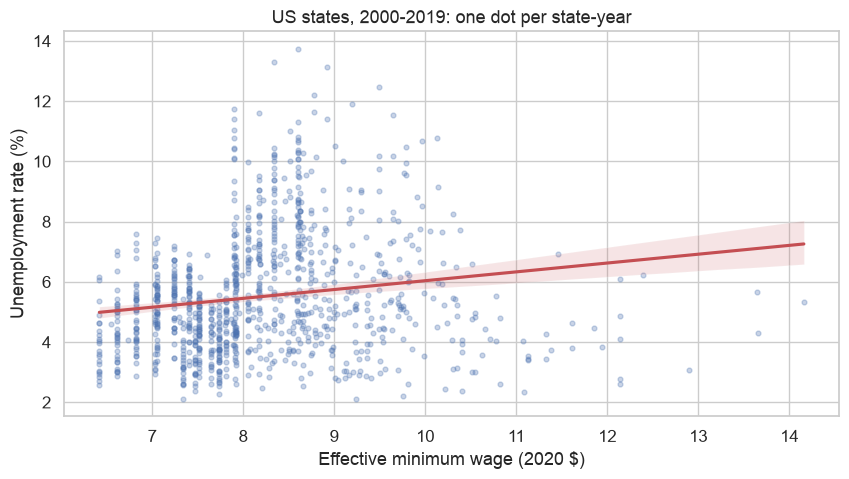

                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       3.1030      0.463      6.701      0.000       2.194       4.012
eff_minwage     0.2934      0.056      5.249      0.000       0.184       0.403


In [3]:
states_yr['eff_minwage'] = states_yr[['minwage', 'fedminwage']].max(axis=1)  # the minimum wage that actually binds

pooled = states_yr[states_yr['year'].between(2000, 2019) & ~states_yr['state'].isin(['los angeles county', 'new york city'])]

sns.regplot(data=pooled, x='eff_minwage', y='unemployment', scatter_kws={'alpha': 0.3, 's': 12}, line_kws={'color': 'C3'})
plt.xlabel('Effective minimum wage (2020 $)')
plt.ylabel('Unemployment rate (%)')
plt.title('US states, 2000-2019: one dot per state-year')
plt.show()

print(smf.ols('unemployment ~ eff_minwage', pooled).fit().summary().tables[1])

The slope is positive and "highly significant": each extra dollar of minimum wage goes with about 0.3 points more unemployment. We still **cannot** read that as the causal effect of the minimum wage. (Also notice that 1,020 state-years are not 1,020 independent observations, which is one reason the p-value is so small.) The problem is **endogeneity**: the minimum wage is correlated with other things that also drive unemployment (in regression terms, $X$ is correlated with the error term).

### Exercise

For the plot above, write one concrete story for each of the three sources of endogeneity from the lecture:

1. **Omitted variable**: something that raises minimum wages *and* changes unemployment.
2. **Simultaneity / reverse causality**: how unemployment might cause minimum wage policy.
3. **Selection**: why the states that choose high minimum wages might not be comparable to those that don't.

*Your answer here (markdown).*

***
## 2. Difference-in-Differences

We would like to see the **counterfactual**: New Jersey's unemployment *with* the policy compared with New Jersey's unemployment *without* it. We only ever see one of these. DiD builds a stand-in: a **control group** whose *change* over time shows what would have happened to the treated group without treatment.

**The natural experiment.** In 2014 New Jersey raised its minimum wage from \$7.25 to \$8.25 and indexed it to inflation. Neighbouring Pennsylvania stayed at the federal \$7.25. This is the same pair of states Card & Krueger used in their classic 1994 study.

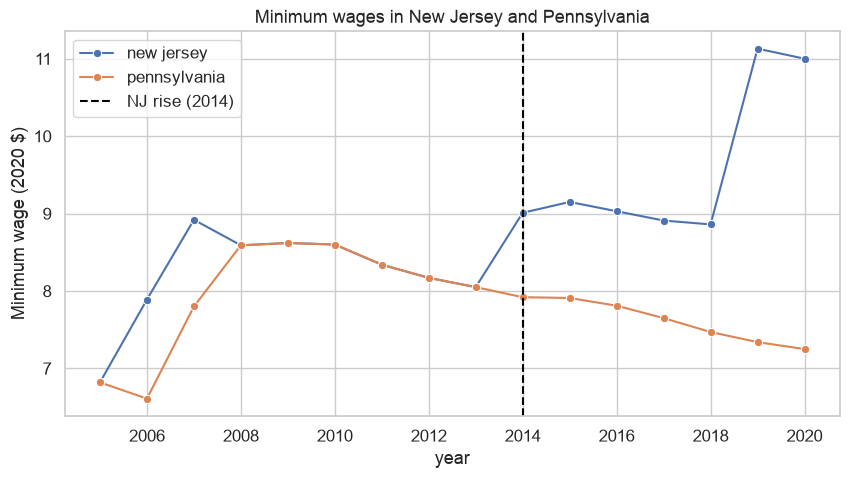

In [4]:
nj_pa = states_yr[states_yr['state'].isin(['new jersey', 'pennsylvania'])]

sns.lineplot(data=nj_pa[nj_pa['year'].between(2005, 2020)], x='year', y='minwage', hue='state', marker='o')
plt.axvline(2014, color='black', ls='--', label='NJ rise (2014)')
plt.ylabel('Minimum wage (2020 $)')
plt.title('Minimum wages in New Jersey and Pennsylvania')
plt.legend()
plt.show()

The lines slope down between rises because the series is inflation-adjusted. Apart from 2006–07, when New Jersey moved first, the two states track each other exactly until 2014. Then New Jersey moves up. (There is a second, much bigger NJ rise in 2019, and then COVID in 2020. We keep our window to **2010–2018** so neither gets mixed in with the 2014 treatment. The lecture calls this "no simultaneous treatment".)

Before any regression, map the outcome. Below is the change in county unemployment from 2013 (the year before the rise) to 2016.

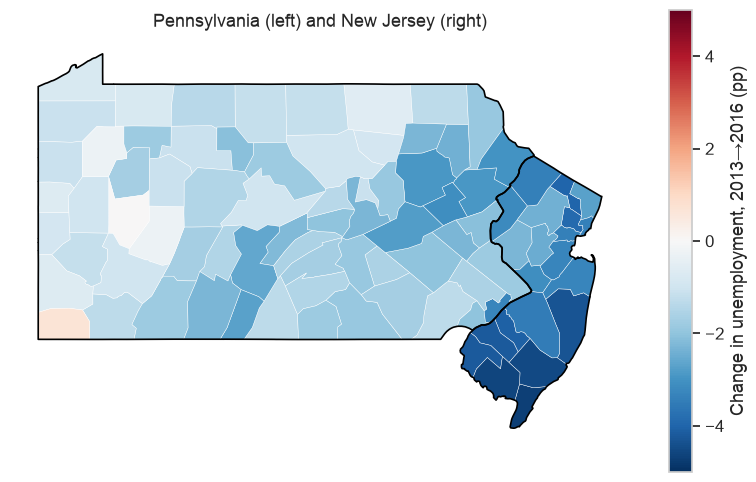

In [5]:
shp = gpd.read_file('https://storage.googleapis.com/qm2/wk10/geojson-counties-fips.json')
shp = shp[shp['STATE'].isin(['34', '42'])]  # 34 = New Jersey, 42 = Pennsylvania

wide = counties.pivot(index='county_fips', columns='year', values='unemployment')
chg = (wide[2016] - wide[2013]).rename('chg').reset_index()
m = shp.merge(chg, left_on='id', right_on='county_fips')

fig, ax = plt.subplots(figsize=(10, 6))
m.plot(column='chg', cmap='RdBu_r', vmin=-5, vmax=5, legend=True, ax=ax, edgecolor='white', linewidth=0.3,
       legend_kwds={'label': 'Change in unemployment, 2013→2016 (pp)'})
m.dissolve('STATE').boundary.plot(ax=ax, color='black', linewidth=1.2)
ax.set_axis_off()
ax.set_title('Pennsylvania (left) and New Jersey (right)')
plt.show()

Unemployment fell (blue) almost everywhere, because the economy was recovering from the 2008 crisis. That is exactly why we can't just look at New Jersey before and after.

### 2.1 Why not just compare before and after?

Two naive comparisons, and what goes wrong with each:

In [6]:
did = nj_pa[nj_pa['year'].between(2010, 2018)].copy()
did['treat'] = (did['state'] == 'new jersey').astype(int)  # 1 = New Jersey (treated), 0 = Pennsylvania (control)
did['post'] = (did['year'] >= 2014).astype(int)          # 1 = after the rise

nj = did[did['treat'] == 1]
print('Naive 1, NJ after minus NJ before :', round(nj.loc[nj.post == 1, 'unemployment'].mean() - nj.loc[nj.post == 0, 'unemployment'].mean(), 2))
post = did[did['post'] == 1]
print('Naive 2, NJ minus PA, after only  :', round(post.loc[post.treat == 1, 'unemployment'].mean() - post.loc[post.treat == 0, 'unemployment'].mean(), 2))

Naive 1, NJ after minus NJ before : -4.02
Naive 2, NJ minus PA, after only  : -0.04


Naive 1 credits the policy with the whole post-recession recovery. Naive 2 mixes the policy up with permanent differences between the two states (industry mix, proximity to New York, and so on). DiD **subtracts one from the other**: New Jersey's change, minus Pennsylvania's change.

### 2.2 The 2x2 table by hand

In [7]:
table = did.pivot_table(index='post', columns='treat', values='unemployment', aggfunc='mean')
table.index = ['Before (2010-13)', 'After (2014-18)']
table.columns = ['PA (control)', 'NJ (treated)']
table['NJ - PA'] = table['NJ (treated)'] - table['PA (control)']
table.loc['After - Before'] = table.loc['After (2014-18)'] - table.loc['Before (2010-13)']
table.round(2)

,PA (control),NJ (treated),NJ - PA
Before (2010-13),7.67,9.20,1.53
After (2014-18),5.22,5.18,-0.04
After - Before,-2.45,-4.02,-1.57


Difference-in-differences: -1.57 percentage points


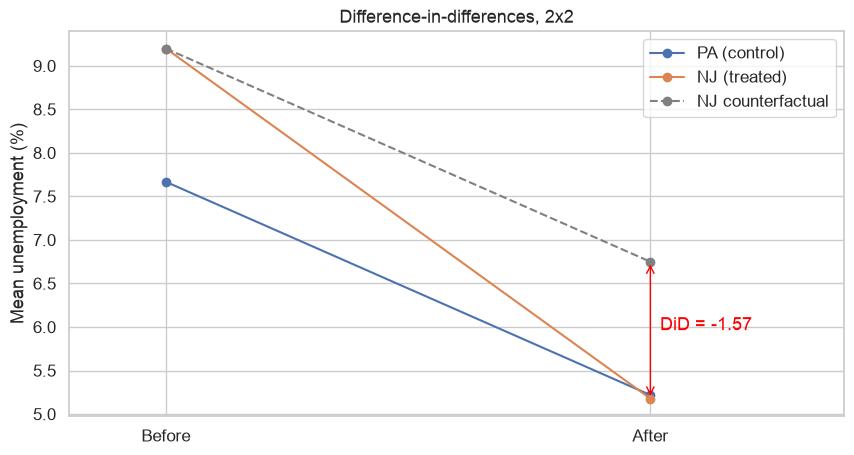

In [8]:
did_by_hand = table.loc['After - Before', 'NJ - PA']
print(f'Difference-in-differences: {did_by_hand:.2f} percentage points')

# the picture from the lecture: the dashed line is NJ's counterfactual (PA's change added to NJ's starting point)
b = table.loc['Before (2010-13)']; a = table.loc['After (2014-18)']
plt.plot([0, 1], [b['PA (control)'], a['PA (control)']], 'o-', label='PA (control)')
plt.plot([0, 1], [b['NJ (treated)'], a['NJ (treated)']], 'o-', label='NJ (treated)')
plt.plot([0, 1], [b['NJ (treated)'], b['NJ (treated)'] + (a['PA (control)'] - b['PA (control)'])], 'o--', color='grey', label='NJ counterfactual')
plt.annotate('', xy=(1, a['NJ (treated)']), xytext=(1, b['NJ (treated)'] + a['PA (control)'] - b['PA (control)']),
             arrowprops=dict(arrowstyle='<->', color='red'))
plt.text(1.02, (a['NJ (treated)'] + b['NJ (treated)'] + a['PA (control)'] - b['PA (control)']) / 2, f'DiD = {did_by_hand:.2f}', color='red')
plt.xticks([0, 1], ['Before', 'After']); plt.xlim(-0.2, 1.4)
plt.ylabel('Mean unemployment (%)'); plt.legend(); plt.title('Difference-in-differences, 2x2')
plt.show()

### Exercise: the Mariel boatlift by hand

In the lecture's case study (Card, 1990), Miami is the treated city and four comparison cities are the control. Unemployment rates (%) were:

| | 1979 | 1981 |
|---|---|---|
| Miami, Black workers | 8.3 | 9.6 |
| Comparison cities, Black workers | 10.3 | 12.6 |

Compute the DiD estimate in the cell below. The standard error on it is 2.8. What do you conclude about the effect of the boatlift on Black workers' unemployment?

In [9]:
# your code here

### 2.3 DiD as a regression

The same number comes out of a regression with an **interaction**:

$$Unemployment_{it} = \beta_0 + \beta_1 Post_t + \beta_2 Treat_i + \beta_3 (Treat_i \times Post_t) + \varepsilon_{it}$$

| | Control (PA) | Treated (NJ) |
|---|---|---|
| **Before** | $\beta_0$ | $\beta_0 + \beta_2$ |
| **After** | $\beta_0 + \beta_1$ | $\beta_0 + \beta_1 + \beta_2 + \beta_3$ |

In a formula, `treat * post` expands to `treat + post + treat:post`. The coefficient on `treat:post` is $\beta_3$, the DiD estimate. The regression also gives us a standard error.

In [10]:
did_ols = smf.ols('unemployment ~ treat * post', data=did).fit()
print(did_ols.summary().tables[1])
print(f"\nbeta_3 = {did_ols.params['treat:post']:.2f}   (by hand: {did_by_hand:.2f})")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.6667      0.362     21.194      0.000       6.891       8.443
treat          1.5312      0.512      2.993      0.010       0.434       2.628
post          -2.4483      0.485     -5.045      0.000      -3.489      -1.407
treat:post    -1.5712      0.686     -2.289      0.038      -3.043      -0.099

beta_3 = -1.57   (by hand: -1.57)


### Exercise

Using only the coefficients in the table above (not the data), rebuild each of the four cells of the 2x2 table. Check that they match `table`.

In [11]:
# your code here  (hint: did_ols.params['Intercept'], did_ols.params['post'], ...)

### 2.4 More data: the county panel and fixed effects

The state regression has only 18 rows (2 states x 9 years). The county file gives us 88 counties x 9 years. That is **panel data**: the same units $i$ observed at several times $t$. Two things change.

1. **Fixed effects.** Counties differ in permanent ways (Philadelphia is not rural Potter County). A **county fixed effect** gives every county its own intercept `C(county_fips)`, so each county acts as its own control. A **year fixed effect** `C(year)` absorbs shocks common to everyone in a year, such as the national recovery. These replace `treat` and `post`, and only the interaction `treat_post` is left to estimate. This is called *two-way fixed effects* (TWFE) DiD.
2. **Clustered standard errors.** One county's nine yearly observations are not nine independent pieces of information. Clustering by county lets the errors be correlated within a county. Without it the standard errors are too small.

In [12]:
panel = counties[counties['state'].isin([34, 42]) & counties['year'].between(2008, 2018)].copy()
panel['treat'] = (panel['state'] == 34).astype(int)
panel['treat_post'] = panel['treat'] * (panel['year'] >= 2014)

p = panel[panel['year'] >= 2010]
twfe = smf.ols('unemployment ~ treat_post + C(county_fips) + C(year)', data=p).fit(
    cov_type='cluster', cov_kwds={'groups': p['county_fips']})
print(f"TWFE DiD estimate: {twfe.params['treat_post']:.2f} pp  (clustered SE {twfe.bse['treat_post']:.2f}, p = {twfe.pvalues['treat_post']:.3g})")

TWFE DiD estimate: -1.68 pp  (clustered SE 0.16, p = 5.01e-25)


A large, "highly significant" drop in unemployment. Before you believe it, remember that clustered standard errors only account for noise *within* counties. All 21 treated counties are in **one** state, and anything else that happened to New Jersey after 2014 would hit every one of them. The p-value can't warn you about that. Only the design checks can. That is the next section.

### 2.5 Parallel trends: the event-study plot

DiD assumes that **without the policy, NJ and PA would have moved in parallel**. We can never test this after 2014, but we can check whether they moved in parallel *before* 2014. First, the raw data:

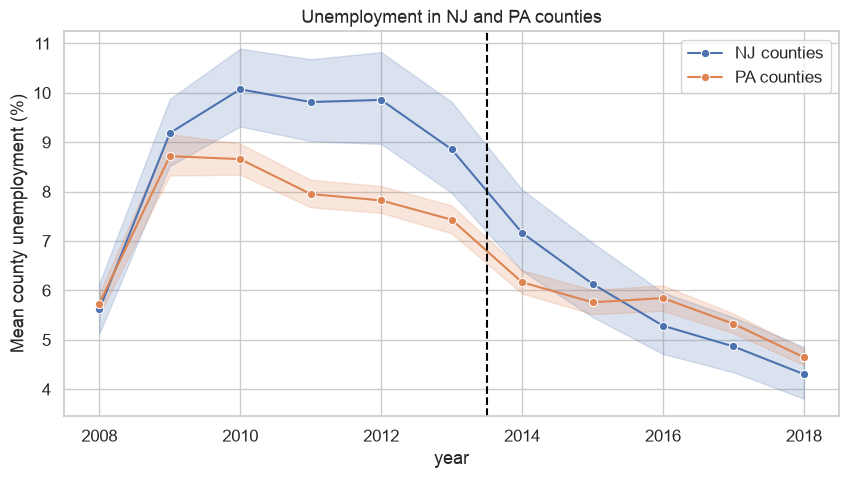

In [13]:
sns.lineplot(data=panel, x='year', y='unemployment', hue=panel['treat'].map({1: 'NJ counties', 0: 'PA counties'}), marker='o')
plt.axvline(2013.5, color='black', ls='--')
plt.ylabel('Mean county unemployment (%)'); plt.title('Unemployment in NJ and PA counties')
plt.legend(title='')
plt.show()

An **event-study** regression makes the pre-trend check precise. Instead of one `treat_post` dummy, we give NJ a separate dummy for *every year* except a reference year (2013, the last pre-treatment year). Each coefficient is the NJ–PA gap in that year *relative to the 2013 gap*.

* Pre-treatment coefficients close to 0 support parallel trends.
* Post-treatment coefficients trace out the effect over time.

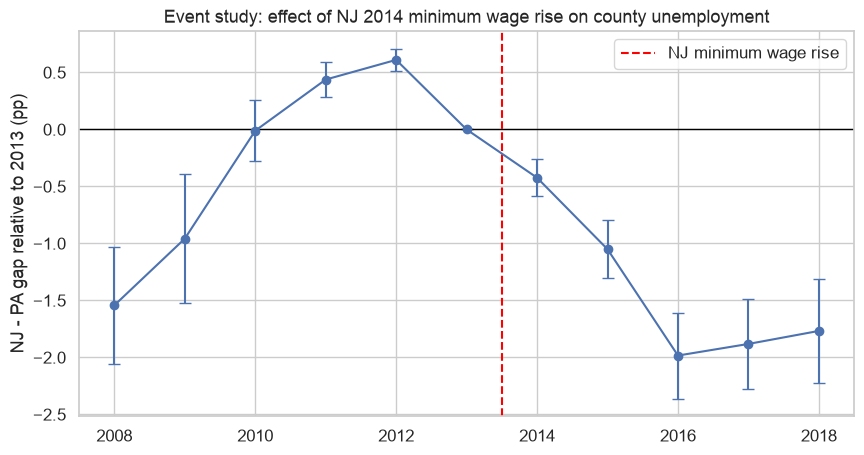

In [14]:
years = [y for y in range(2008, 2019) if y != 2013]
for y in years:
    panel[f'nj_{y}'] = ((panel['year'] == y) & (panel['treat'] == 1)).astype(int)

formula = 'unemployment ~ ' + ' + '.join(f'nj_{y}' for y in years) + ' + C(county_fips) + C(year)'
es = smf.ols(formula, data=panel).fit(cov_type='cluster', cov_kwds={'groups': panel['county_fips']})

coefs = pd.DataFrame({'year': years,
                      'b': [es.params[f'nj_{y}'] for y in years],
                      'se': [es.bse[f'nj_{y}'] for y in years]})
coefs = pd.concat([coefs, pd.DataFrame({'year': [2013], 'b': [0.0], 'se': [0.0]})]).sort_values('year')

plt.errorbar(coefs['year'], coefs['b'], yerr=1.96 * coefs['se'], fmt='o-', capsize=4)
plt.axhline(0, color='black', lw=1)
plt.axvline(2013.5, color='red', ls='--', label='NJ minimum wage rise')
plt.ylabel('NJ - PA gap relative to 2013 (pp)')
plt.title('Event study: effect of NJ 2014 minimum wage rise on county unemployment')
plt.legend()
plt.show()

### Exercise

Look carefully at the pre-2014 coefficients.

1. Are the pre-treatment trends parallel? Describe what happened to the NJ–PA gap between 2008 and 2012.
2. Suggest an economic reason for that pattern. (Hint: which state was hit harder by the 2008 financial crisis? What usually happens to a place that falls further in a recession, once the recovery comes?)
3. Given this, is the TWFE estimate from 2.4 more likely to *overstate* or *understate* the job-creating effect of the minimum wage? Why?

*Your answer here.*

### 2.6 Placebo tests

The lecture listed ways to check the equal-trend assumption beyond looking at a plot. Two of them are easy here.

**(a) Fake treatment date.** Use only the pre-treatment years and pretend the policy happened in 2012. There was no policy then, so a real design should find ~0.

In [15]:
pre = panel[panel['year'].between(2010, 2013)].copy()
pre['fake_post'] = pre['treat'] * (pre['year'] >= 2012)
placebo = smf.ols('unemployment ~ fake_post + C(county_fips) + C(year)', data=pre).fit(
    cov_type='cluster', cov_kwds={'groups': pre['county_fips']})
print(f"Placebo (fake 2012 treatment): {placebo.params['fake_post']:.2f} pp, p = {placebo.pvalues['fake_post']:.3f}")

Placebo (fake 2012 treatment): 0.09 pp, p = 0.375


This window passes, because 2010–2013 is the flat part of the event-study plot. If you move the window earlier, into 2008–2011, it would not.

**(b) Fake treatment group.** Most states did not change their minimum wage in 2014. If we run the *same* state-level DiD with Pennsylvania as control but a **different, untreated state** as the "treated" group, we should get roughly zero. If lots of untreated states show "effects" as big as New Jersey's, then NJ's estimate is not special.

### Exercise

1. Write a loop over every state in `states_yr` except Pennsylvania (and the two city rows, `'los angeles county'` and `'new york city'`). For each one, build the same 2010–2018 dataset as in 2.3 with that state as `treat = 1`, fit `unemployment ~ treat * post`, and store the `treat:post` coefficient.
2. Plot a histogram of the placebo estimates, with a vertical line at New Jersey's estimate (`did_ols.params['treat:post']`).
3. Roughly what share of states show a drop at least as large as New Jersey's? What does that say about how much we should trust the NJ result? (Many of those states did not raise their minimum wage at all in 2014. What else do the states with big "effects" have in common?)

In [16]:
placebo_effects = {}
for st in states_yr['state'].unique():
    # your code here
    pass

### *Optional*: sensitivity to the time window

The window 2010–2018 was our choice. Re-estimate the state-level DiD for windows of ±1, ±2, …, ±6 years around 2014, and plot the estimate (with a 95% CI) against the window width. Does the answer depend on the choice?

In [17]:
# your code here

***
## 3. Regression Discontinuity

DiD needs a before and an after. RDD needs a **cutoff** instead: treatment is switched on when a continuous *running variable* crosses a known threshold. Units just below and just above the cutoff are alike in every other way, so comparing them gives the effect of treatment **at the cutoff**.

### Is alcohol killing you?

In the U.S. the legal drinking age is 21. People who are 20 years and 11 months old are, on average, the same as people who are 21 years and 1 month old, except that the second group can drink legally. Carpenter & Dobkin (2009) used this to estimate the effect of alcohol access on mortality. Each row below is a one-month age cell. The outcomes are deaths per 100,000 person-years: all causes (`all`), motor vehicle accidents (`mva`), suicide (`suicide`), and internal causes such as disease (`internal`).

We **centre** the running variable at the cutoff (age − 21). The cutoff is then at 0, and regression intercepts become values *at* the cutoff.

In [18]:
drinking = pd.read_csv('https://storage.googleapis.com/qm2/rdd/drinking.csv')
drinking['age'] = drinking['agecell'] - 21            # running variable, centred at the cutoff
drinking['over21'] = (drinking['age'] >= 0).astype(int)  # treatment: legally allowed to drink
drinking[['agecell', 'age', 'over21', 'all', 'mva', 'suicide', 'internal']].head()

,agecell,age,over21,all,mva,suicide,internal
0,19.068493,-1.931507,0,92.825400,35.829327,11.203714,16.617590
1,19.150684,-1.849316,0,95.100740,35.639256,12.193368,18.327684
2,19.232876,-1.767124,0,92.144295,34.205650,11.715812,18.911053
3,19.315070,-1.684930,0,88.427760,32.278957,11.275010,16.101770
4,19.397260,-1.602740,0,88.704940,32.650967,10.984314,17.363520


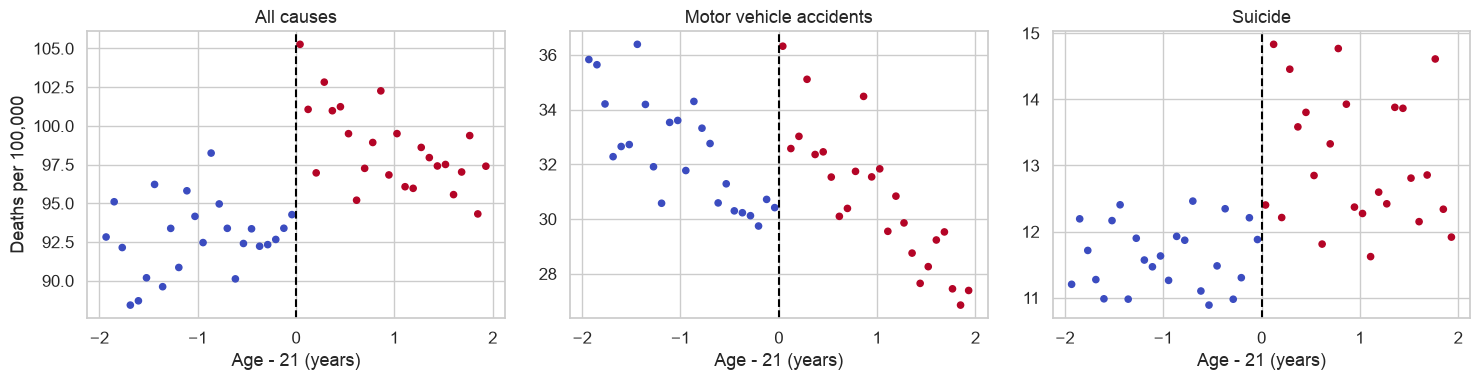

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, col, title in zip(axes, ['all', 'mva', 'suicide'], ['All causes', 'Motor vehicle accidents', 'Suicide']):
    ax.scatter(drinking['age'], drinking[col], c=drinking['over21'], cmap='coolwarm', s=20)
    ax.axvline(0, color='black', ls='--')
    ax.set_title(title); ax.set_xlabel('Age - 21 (years)')
axes[0].set_ylabel('Deaths per 100,000')
plt.tight_layout(); plt.show()

There is a visible jump at 21. The two assumptions from the lecture are what make it causal:

1. **No manipulation of the running variable.** People can't choose their age. We check the density in 3.4.
2. **Everything else is continuous at the cutoff.** Nothing else changes exactly at 21 that would also affect deaths. We test this indirectly with a placebo outcome in 3.4.

### 3.1 Linear, different slopes

Fit one line below the cutoff and another above, and measure the gap between them *at* the cutoff:

$$y_i = \beta_0 + \beta_1\, age_i + \beta_2\, \mathbb{1}\{age_i \ge 0\} + \beta_3\, \mathbb{1}\{age_i \ge 0\} \times age_i + \varepsilon_i$$

$\beta_0$ is the predicted value just below 21, $\beta_0 + \beta_2$ just above, and **$\beta_2$ is the jump**, our treatment effect. The interaction lets the slope differ on each side.

In [20]:
rdd = smf.ols('all ~ age * over21', data=drinking).fit()
print(rdd.summary().tables[1])

jump = rdd.params['over21']
print(f"\nJump at 21: {jump:.2f} deaths per 100,000  ({100 * jump / rdd.params['Intercept']:.1f}% of the just-under-21 rate)")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     93.6184      0.932    100.399      0.000      91.739      95.498
age            0.8270      0.819      1.010      0.318      -0.823       2.477
over21         7.6627      1.319      5.811      0.000       5.005      10.320
age:over21    -3.6034      1.158     -3.111      0.003      -5.937      -1.269

Jump at 21: 7.66 deaths per 100,000  (8.2% of the just-under-21 rate)


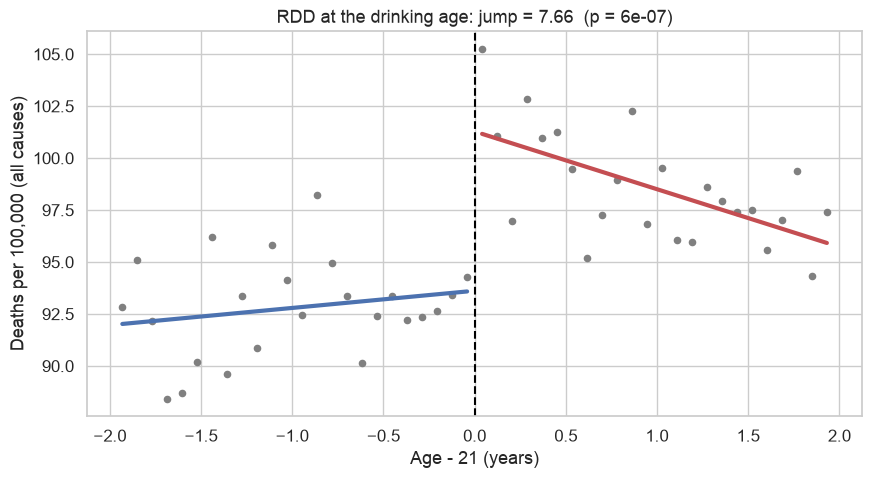

In [21]:
d = drinking.dropna(subset=['all']).assign(fit=rdd.fittedvalues)
plt.scatter(d['age'], d['all'], color='grey', s=20)
for side in [0, 1]:
    s = d[d['over21'] == side]
    plt.plot(s['age'], s['fit'], lw=3, color=['C0', 'C3'][side])
plt.axvline(0, color='black', ls='--')
plt.xlabel('Age - 21 (years)'); plt.ylabel('Deaths per 100,000 (all causes)')
plt.title(f'RDD at the drinking age: jump = {jump:.2f}  (p = {rdd.pvalues["over21"]:.1g})')
plt.show()

### Exercise: a non-linear specification

The lecture also showed a **non-linear** design. Add a squared term on each side (`age + I(age**2)` interacted with `over21`) and re-estimate the jump for `all`. Plot the fitted curves as above. Does the estimate move much? Why can high-order polynomials be risky in RDD? (Think about what happens to a curve at the *edge* of the data, which is exactly where the cutoff is.)

In [22]:
# your code here

### 3.2 Bandwidth: how close is "close"?

The design is most credible *near* the cutoff: a 19-year-old and a 23-year-old differ in many ways. The **bandwidth** $h$ restricts the sample to $|age| \le h$. A smaller $h$ means more comparable units (less bias) but fewer observations (more noise). A common refinement is a **triangular kernel**, which down-weights points further from the cutoff:

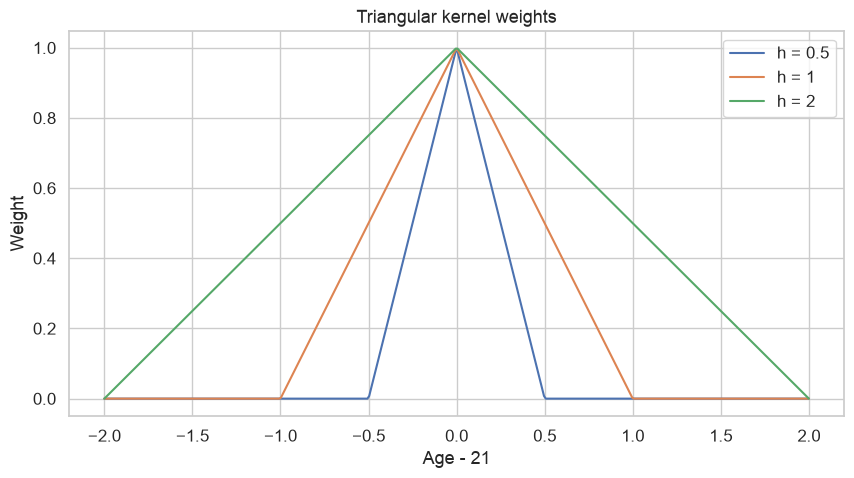

In [23]:
def triangular(r, h):
    # weight = 1 at the cutoff, falling linearly to 0 at distance h
    return np.clip(1 - np.abs(r) / h, 0, None)

r = np.linspace(-2, 2, 400)
for h in [0.5, 1, 2]:
    plt.plot(r, triangular(r, h), label=f'h = {h}')
plt.xlabel('Age - 21'); plt.ylabel('Weight'); plt.title('Triangular kernel weights'); plt.legend()
plt.show()

A robust result should not depend much on the bandwidth. The loop below re-estimates the jump for a range of bandwidths, using weighted least squares (`smf.wls`) with triangular weights, and plots the estimates with 95% confidence intervals.

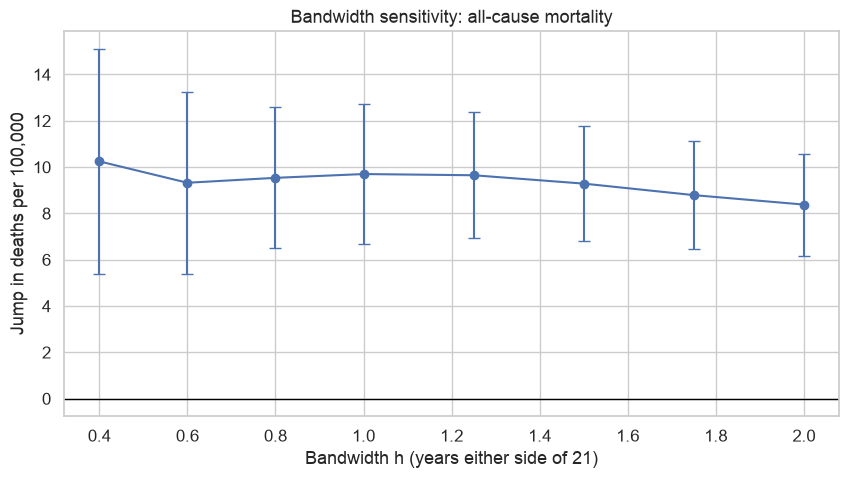

,h,jump,se,n
0,0.40,10.25,2.48,10
1,0.60,9.32,2.01,14
2,0.80,9.54,1.55,20
3,1.00,9.70,1.53,24
4,1.25,9.65,1.39,30
5,1.50,9.29,1.27,36
6,1.75,8.79,1.19,42
7,2.00,8.38,1.12,48


In [24]:
def rdd_jump(outcome, h, data=drinking):
    s = data.dropna(subset=[outcome])
    s = s[s['age'].abs() <= h]
    m = smf.wls(f'{outcome} ~ age * over21', data=s, weights=triangular(s['age'], h)).fit()
    return m.params['over21'], m.bse['over21'], len(s)

bws = [0.4, 0.6, 0.8, 1.0, 1.25, 1.5, 1.75, 2.0]
res = pd.DataFrame([(h, *rdd_jump('all', h)) for h in bws], columns=['h', 'jump', 'se', 'n'])

plt.errorbar(res['h'], res['jump'], yerr=1.96 * res['se'], fmt='o-', capsize=4)
plt.axhline(0, color='black', lw=1)
plt.xlabel('Bandwidth h (years either side of 21)'); plt.ylabel('Jump in deaths per 100,000')
plt.title('Bandwidth sensitivity: all-cause mortality')
plt.show()
res.round(2)

Notice the trade-off: at small $h$ the confidence intervals widen because each side has only a handful of age cells.

### 3.3 Validity checks

**(a) Placebo outcome.** If the jump really comes from alcohol, it should show up in deaths alcohol plausibly causes (accidents, alcohol poisoning), and **not** in deaths it doesn't (e.g. `internal` causes such as cancer and other diseases). If "internal" deaths also jumped at 21, we would suspect something else changes at that age.

### Exercise

Use `rdd_jump` to run the bandwidth loop for `internal` and for `mva`, and plot all three outcomes (`all`, `mva`, `internal`) on one figure. Then answer:

1. Which outcome behaves like a good placebo?
2. Does the `internal` estimate stay near zero at *every* bandwidth? What would you tell a reader about any exceptions?

In [25]:
# your code here

**(b) Manipulation: the McCrary density test.** If units can move themselves across the cutoff, the people just above it are no longer comparable to those just below. The signature is **bunching**: too many observations just on the "good" side. Age can't be manipulated, so we use the lecture's other example, an exam.

In Texas, students must pass a last-chance exit exam to receive a high-school diploma. `sheepskin.csv` groups students by their score relative to the pass mark (`minscore`, where 0 = the pass mark). `n` is the number of students in each score cell, and that is the density we check. A spike at 0 would mean teachers nudging marginal students over the line.

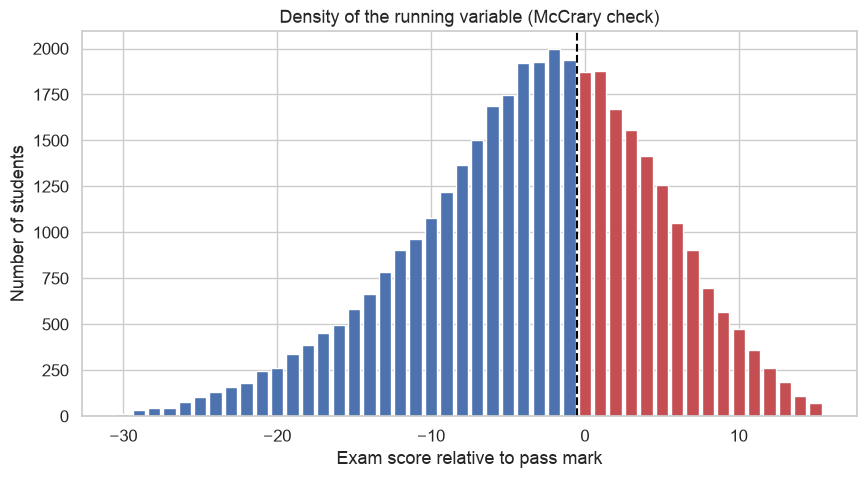

Jump in log density at the pass mark: -0.037 (about -4%), p = 0.66


In [26]:
sheepskin = pd.read_csv('https://storage.googleapis.com/qm2/rdd/sheepskin.csv')
sheepskin['passed'] = (sheepskin['minscore'] >= 0).astype(int)  # a score of exactly 0 is a pass

plt.bar(sheepskin['minscore'], sheepskin['n'], color=np.where(sheepskin['passed'] == 1, 'C3', 'C0'))
plt.axvline(-0.5, color='black', ls='--')
plt.xlabel('Exam score relative to pass mark'); plt.ylabel('Number of students')
plt.title('Density of the running variable (McCrary check)')
plt.show()

# a simple version of McCrary's test: fit a line to log(count) on each side of the cutoff and measure the jump
near = sheepskin[sheepskin['minscore'].abs() <= 10]
dens = smf.ols('np.log(n) ~ minscore * passed', data=near).fit()
print(f"Jump in log density at the pass mark: {dens.params['passed']:.3f} (about {100 * dens.params['passed']:.0f}%), p = {dens.pvalues['passed']:.2f}")

The density is smooth across the pass mark. The estimated jump is small, not significant, and if anything *negative*, when manipulation would produce a spike just above the line. If markers had been rounding up students who scored −1 or −2, you would see a dip just left of the line and a spike just right of it.

***
## *Optional*: fuzzy RDD and the sheepskin effect

Does a diploma raise earnings because school made you more productive, or because the certificate itself (the "sheepskin") signals quality to employers? Students who barely passed and barely failed the exam have nearly the same skills, but only one group gets the certificate.

Here passing does **not** fully determine treatment. Some students who fail still get a diploma later, and some who pass don't. This is a **fuzzy** RDD: the cutoff causes a jump in the *probability* of treatment, not a jump from 0 to 1.

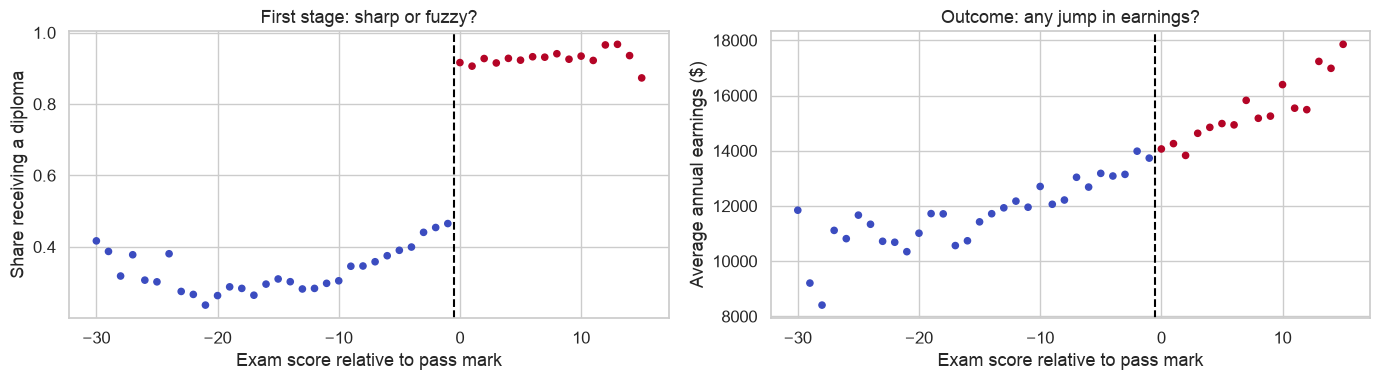

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, lab in zip(axes, ['receivehsd', 'avgearnings'], ['Share receiving a diploma', 'Average annual earnings ($)']):
    ax.scatter(sheepskin['minscore'], sheepskin[col], c=sheepskin['passed'], cmap='coolwarm', s=20)
    ax.axvline(-0.5, color='black', ls='--'); ax.set_xlabel('Exam score relative to pass mark'); ax.set_ylabel(lab)
axes[0].set_title('First stage: sharp or fuzzy?'); axes[1].set_title('Outcome: any jump in earnings?')
plt.tight_layout(); plt.show()

The fuzzy-RDD estimate (a *Wald* or instrumental-variables estimator) divides the jump in the outcome by the jump in the treatment probability:

$$\text{effect of a diploma} = \frac{\text{jump in earnings at the cutoff}}{\text{jump in P(diploma) at the cutoff}}$$

In [28]:
def fuzzy_jump(data, h=15):
    s = data[data['minscore'].abs() <= h]
    w = triangular(s['minscore'], h) * s['n']  # kernel weight x cell size
    num = smf.wls('avgearnings ~ minscore * passed', data=s, weights=w).fit().params['passed']
    den = smf.wls('receivehsd ~ minscore * passed', data=s, weights=w).fit().params['passed']
    return num, den, num / den

num, den, wald = fuzzy_jump(sheepskin)
print(f'Jump in earnings (reduced form): ${num:,.0f}')
print(f'Jump in P(diploma) (first stage): {den:.2f}')
print(f'Fuzzy RDD effect of a diploma:    ${wald:,.0f}')

Jump in earnings (reduced form): $14
Jump in P(diploma) (first stage): 0.43
Fuzzy RDD effect of a diploma:    $32


### *Optional* Exercise

Get a 95% confidence interval for the Wald estimate by bootstrapping: resample the rows of `sheepskin` with replacement 500 times (`sheepskin.sample(frac=1, replace=True)`), recompute `fuzzy_jump` each time, and take the 2.5th and 97.5th percentiles. Plot the bootstrap distribution. Is there a sheepskin effect?

In [29]:
# your code here

***
## 4. Audit a causal claim

You will increasingly be asked to *judge* analyses rather than write them: a think-tank report, a newspaper chart, code an AI assistant produced. Below are two analyses that run without errors and report significant p-values. **Both are flawed.** Use the lecture's checklist:

* **What is the counterfactual**, and why should I believe it?
* **DiD**: were pre-treatment trends parallel? Does a placebo group or fake date show an "effect"? Did anything else change at the same time?
* **RDD**: could people manipulate the running variable? Do other characteristics jump at the cutoff? Does the estimate survive a different bandwidth or functional form?
* **Who does it apply to?** DiD: the treated group. RDD: only units near the cutoff.

### Claim A

> *"New Jersey's January 2020 minimum wage increase to \$11 destroyed jobs. Using a two-way fixed-effects difference-in-differences design on all 88 counties of New Jersey and Pennsylvania (2016–2021), with county and year fixed effects and clustered standard errors, we find the increase raised county unemployment by 1.3 percentage points (p < 0.001)."*

In [30]:
# the analysis behind Claim A (it runs fine; the problem is the design)
claim = counties[counties['state'].isin([34, 42]) & counties['year'].between(2016, 2021)].copy()
claim['treat_post'] = ((claim['state'] == 34) & (claim['year'] >= 2020)).astype(int)
claim_a = smf.ols('unemployment ~ treat_post + C(county_fips) + C(year)', data=claim).fit(
    cov_type='cluster', cov_kwds={'groups': claim['county_fips']})
print(f"Estimate: {claim_a.params['treat_post']:.2f} pp, p = {claim_a.pvalues['treat_post']:.1g}")

Estimate: 1.30 pp, p = 1e-06


### Claim B

> *"Crossing the drinking age raises suicides by 15%. Therefore raising the U.S. drinking age from 21 to 25 would cut suicides among 21–24-year-olds by 15%."*

In [31]:
# the analysis behind Claim B: the analyst tried several bandwidths and reported this one
s = drinking.dropna(subset=['suicide'])
claim_b = smf.ols('suicide ~ age * over21', data=s).fit()  # all data, |age| <= 2
print(f"Jump: {claim_b.params['over21']:.2f}  = {100 * claim_b.params['over21'] / claim_b.params['Intercept']:.0f}% increase, p = {claim_b.pvalues['over21']:.1g}")

Jump: 1.79  = 15% increase, p = 0.0003


### Exercise: write the audit

For **each** claim:

1. Go through the checklist and identify **at least two** problems. For each, say whether it would make the estimate too big, too small, or just uninterpretable.
2. Run **one** piece of code that provides evidence for one of your problems. Ideas: an event-study plot for Claim A (which years are pre-treatment? what happened in 2020?); `rdd_jump('suicide', h)` across bandwidths for Claim B.
3. Rewrite the claim as one honest sentence that the evidence *does* support.

In [32]:
# Claim A: your code here

In [33]:
# Claim B: your code here

*Your audit here.*

***
## References

* Card, D. & Krueger, A. (1994). [Minimum Wages and Employment: A Case Study of the Fast-Food Industry in New Jersey and Pennsylvania](https://davidcard.berkeley.edu/papers/njmin-aer.pdf). *American Economic Review*.
* Card, D. (1990). The Impact of the Mariel Boatlift on the Miami Labor Market. *Industrial and Labor Relations Review*.
* Carpenter, C. & Dobkin, C. (2009). [The Effect of Alcohol Consumption on Mortality: Regression Discontinuity Evidence from the Minimum Drinking Age](https://www.aeaweb.org/articles?id=10.1257/app.1.1.164). *AEJ: Applied Economics*.
* Clark, D. & Martorell, P. (2014). The Signaling Value of a High School Diploma. *Journal of Political Economy*.
* The RDD section adapts Chapter 16 of Matheus Facure's [Causal Inference for the Brave and True](https://github.com/matheusfacure/python-causality-handbook) (MIT licence).